## import

In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from auditoryforage.AF_env import AuditoryForaging as AF
from auditoryforage.AF_env import AuditoryForagingReward as AFR
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2
from stable_baselines3 import PPO
from irc_gym.irc.model import FuncBeliefModel
from multiprocessing import Pool
import multiprocessing as mp
from matplotlib import pyplot as plt
import numpy as np
from collections import defaultdict
import seaborn as sns
import multiprocessing
from ult import *

In [42]:
food_reward_list = np.linspace(10,2500,5)
env_param = [0, 1500, 0.087213, .25, -30, 0, 0]
task = AFR2(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
num_epochs = 1
task.food_reward_list = food_reward_list

taskbelief = FuncBeliefModel(env=task, rng=1)

agent=PPO.load('ycstore/15thcheckpoint', device='cpu')


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [43]:
# run mp job
no_episodes = 9999


def eval_wrapper(a):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=agent,num_steps=100000)
    food_reward_idx,hit_count,miss_count,false_alarm_count,noise_time_before_lick,signal_time_before_lick,total_noise_time,total_signal_time,total_reward,attention_time_points_across_episodes,episode_length_across_episodes,hit_reaction_time_across_episodes,fa_reaction_time_across_episodes = process_one_episode(
        episode, task)
    return (food_reward_idx,
            hit_count,
            miss_count,
            false_alarm_count,
            noise_time_before_lick,
            signal_time_before_lick,
            total_noise_time,
            total_signal_time,
            total_reward,
            attention_time_points_across_episodes,
            episode_length_across_episodes,
            hit_reaction_time_across_episodes,
            fa_reaction_time_across_episodes
            )


with multiprocessing.Pool(processes=13) as pool:
    results = pool.map(eval_wrapper, range(no_episodes))

# process the mp results
hit_count_list = [[0] for _ in range(len(food_reward_list))]
miss_count_list = [[0] for _ in range(len(food_reward_list))]
false_alarm_list = [[0] for _ in range(len(food_reward_list))]

noise_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
signal_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
total_noise_time_list = [[0] for _ in range(len(food_reward_list))]
total_signal_time_list = [[0] for _ in range(len(food_reward_list))]

for res in results:
    (food_reward_idx,
     hit_count,
     miss_count,
     false_alarm_count,

     noise_time_before_lick,
     signal_time_before_lick,
     total_noise_time,
     total_signal_time,

     total_reward,

     attention_time_points_across_episodes,
     episode_length_across_episodes,
     hit_reaction_time_across_episodes,
     fa_reaction_time_across_episodes
     ) = res

    hit_count_list[food_reward_idx][0] += (hit_count)
    miss_count_list[food_reward_idx][0] += (miss_count)
    false_alarm_list[food_reward_idx][0] += (false_alarm_count)

    noise_time_before_lick_list[food_reward_idx][0] += (noise_time_before_lick)
    signal_time_before_lick_list[food_reward_idx][0] += (
        signal_time_before_lick)
    total_noise_time_list[food_reward_idx][0] += (total_noise_time)
    total_signal_time_list[food_reward_idx][0] += (total_signal_time)

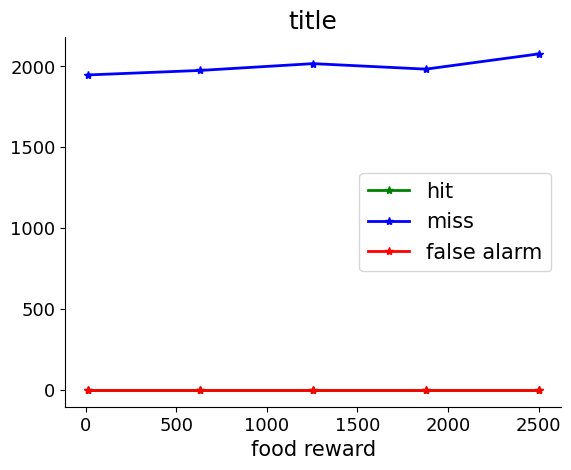

In [44]:
plot_hit_miss_FA(food_reward_list, hit_count_list, miss_count_list, false_alarm_list, 'title')

## mp with multi seed (agent)

In [46]:
# run mp job
signal_time_before_lick_list_list=[]
no_episodes=9999
for seed in range(5): # here for now i just run the same agent number of timee and treat this as seeed. it should be i train multiple agent and run those agents.
    
    def eval_wrapper(a):
        episode = run_one_episode(task=task, taskbelief=taskbelief, agent=agent,
                                num_steps=100000)
        food_reward_idx,              hit_count,            miss_count,             false_alarm_count,             noise_time_before_lick,            signal_time_before_lick,            total_noise_time,            total_signal_time,            total_reward,            attention_time_points_across_episodes,            episode_length_across_episodes,            hit_reaction_time_across_episodes,            fa_reaction_time_across_episodes = process_one_episode(
            episode, task)
        return (food_reward_idx,  
                hit_count,
                miss_count, 
                false_alarm_count, 
                noise_time_before_lick,
                signal_time_before_lick,
                total_noise_time,
                total_signal_time,
                total_reward,
                attention_time_points_across_episodes ,
                episode_length_across_episodes,
                hit_reaction_time_across_episodes ,
                fa_reaction_time_across_episodes
                )
    with multiprocessing.Pool(processes=13) as pool:
        results = pool.map(eval_wrapper, range(no_episodes))

    # process the mp results
    hit_count_list = [[0] for _ in range(len(food_reward_list))]
    miss_count_list = [[0] for _ in range(len(food_reward_list))]
    false_alarm_list = [[0] for _ in range(len(food_reward_list))]

    noise_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
    signal_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
    total_noise_time_list = [[0] for _ in range(len(food_reward_list))]
    total_signal_time_list = [[0] for _ in range(len(food_reward_list))]

    for res in results:
        (food_reward_idx,  
                hit_count,
                miss_count, 
                false_alarm_count, 

                noise_time_before_lick,
                signal_time_before_lick,
                total_noise_time,
                total_signal_time,

                total_reward,
                
                attention_time_points_across_episodes ,
                episode_length_across_episodes,
                hit_reaction_time_across_episodes ,
                fa_reaction_time_across_episodes
                )=res
        
        hit_count_list[food_reward_idx][0] += (hit_count)
        miss_count_list[food_reward_idx][0]+=(miss_count)
        false_alarm_list[food_reward_idx][0]+=(false_alarm_count)

        noise_time_before_lick_list[food_reward_idx][0]+=(noise_time_before_lick)
        signal_time_before_lick_list[food_reward_idx][0]+=(signal_time_before_lick)
        total_noise_time_list[food_reward_idx][0]+=(total_noise_time)
        total_signal_time_list[food_reward_idx][0]+=(total_signal_time)

    signal_time_before_lick_list_list.append(signal_time_before_lick_list)
signal_time_before_lick_list_list=np.array(signal_time_before_lick_list_list)[:,:,0]

KeyboardInterrupt: 

## plot

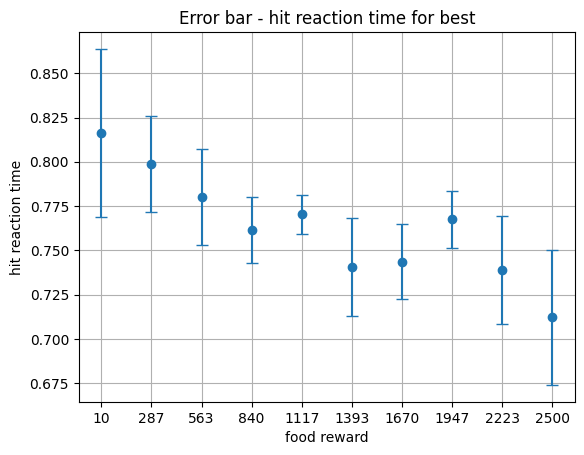

In [ ]:
plt.figure()
mean_list = np.mean(signal_time_before_lick_list_list, axis=0)
sem_list = np.std(signal_time_before_lick_list_list, axis=0)
plt.errorbar([str(food_reward) for food_reward in food_reward_list], mean_list, yerr= sem_list, fmt='o', markersize=6, capsize=4)
plt.xlabel('food reward')
plt.ylabel(f'hit reaction time')
plt.title(f'Error bar - hit reaction time for best')
plt.xticks([ind for ind in range(len(food_reward_list))], [f'{food_reward:.0f}' for food_reward in food_reward_list])
plt.grid()
plt.show()
